# Lab 02

> In this lab, you're going to:

1.   Implement Q agent and SARSA agent
2.   Study about on-policy, off-policy and how they trade-off convergence speed for sample-efficiency
3.   Create simple plot to visualize your agent's results

> **NOTICE 1**: This lab calls to the ***MABe_agent*** class of previous lab. **IF** you have not finish the previous lab, you should not be aable to complete this lab

> **NOTICE 2**: Convert your previous lab's solution or instructor's solution to format **.py** then place that file in this file's directory. We're going to inherit some classes.

> **NOTICE 3**: This lab's solution **will not** be given due to the inheritance of the given lab 01's solution. You can easily implement Q-learning and SARSA by changing the estimation fomula.





Also this lab, we're going to reuse last week's environment: **GridWorld**. The different is our agent. If you don't remember what is GridWorld, please revise your last lab excercise in advance

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]
 [48 49 50 51 52 53 54 55]
 [56 57 58 59 60 61 62 63]]
i = 0|Start at 17 results at 56 get Reward: -15
i = 1|Start at 18 results at 56 get Reward: -15
i = 2|Start at 19 results at 56 get Reward: -15
i = 3|Start at 21 results at 56 get Reward: -15
i = 4|Start at 25 results at 56 get Reward: -15
i = 5|Start at 33 results at 56 get Reward: -15
i = 6|Start at 41 results at 56 get Reward: -15
i = 7|Start at 42 results at 56 get Reward: -15
i = 8|Start at 43 results at 56 get Reward: -15
i = 9|Start at 46 results at 56 get Reward: -15
i = 10|Start at 47 results at 56 get Reward: -15
i = 11|Start at 47 results at 56 get Reward: -15
i = 12|Start at 15 results at 56 get Reward: 15
i = 13|Start at 1 results at 10 get Reward: 5
i = 14|Start at 26 results at 56 get Reward: 20
iter: 100	 Total reward: -70	 Average: -0.7070707070707071
iter

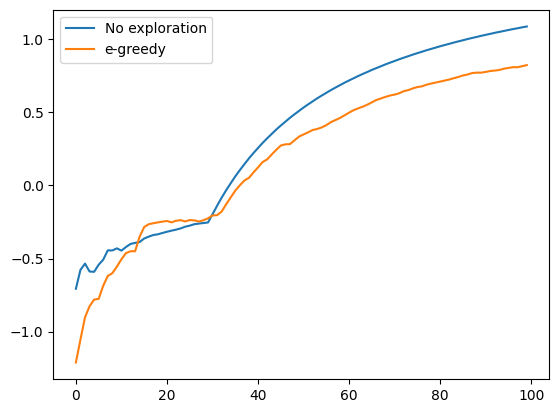

In [7]:
from Lab01 import environment, MABe_agent

Estimation updates:
>Q-learning:
$Q(S_t,A_t) = (1-\alpha)Q(S_t,A_t) + \alpha(R + \gamma max_a Q(S_{t+1},a))$

>SARSA:
$Q(S_t, A_t) = (1-\alpha)Q(S_t,A_t) + \alpha(R + \gamma Q(S_{t+1},A_{t+1}))$



---
On-policy and Off-policy 
---
1. On-policy:
  
  **On-policy** is a group of reinforcement learning methods that **use the value resulting from a different policy to update the current policy**

2. Off-policy:

  **Off-policy** is a group of reinforcement learning methods that **use the value resulting directly from the current policy to update itself**

3. On-policy, off-policy, cons & pros:

*   Off-policy methods are usually learning more about the environment they can use multiple policies' experience. Thus, they're more data-sampling efficient. Famous: *Q-learning, DQN and its extensions*

*   On-policy methods are usually more realistic (most of the time, we can only depend on our own policy for the data we can collect, especially in policy-based methods) and fast converging but not as sampling-efficient as off-policy methods




## Q-learning method

In this section, we're going to implement tabular Q-learning agent and see its performance.

Q-agent inherits from MABe-agent we implemented earlier in this course

In [13]:
from collections import defaultdict
import numpy as np

# Implement your agent
class Q_agent(MABe_agent):
  def __init__(self, envir, init_location, epsilon):
    super(Q_agent, self).__init__(envir, init_location, epsilon)
    # TODO: initialize your Q table
    # self.Q_table, prev_state, last_action already initialize

  # Overide method
  def getAction(self, observation):
    # TODO: return your action
    location_now, action_space, pre_reward = observation
    # NOTICE: the first observation is (NONE, [0,1,2,3], None)
    # You should process the 'None' value
    if location_now is not None:
      self.location_now = location_now

    if pre_reward is None: #first step
      action = np.random.choice(action_space)
      self.prev_state = self.location_now
      self.prev_action = action
      return action
      
    # example: get random action
    # action = np.random.choice(action_space, p=[1/(len(action_space)) for action in action_space])

    #Qlearning
    list_value = [self.Q_table[(self.location_now, a)] for a in action_space]
    max_value = max(list_value)
    best_actions = [a for a, v in zip(action_space, list_value) if v == max_value]
    action = np.random.choice(best_actions)

    #update Q_Table (Q_learning)
    alpha = 0.3
    gamma = 0.3
    self.reward_trace.append(pre_reward)
    new_Q = (1 - alpha) * self.Q_table[(self.prev_state, self.prev_action)] + alpha * (pre_reward + gamma * max_value)
    self.Q_table[(self.prev_state, self.prev_action)] = new_Q

    self.prev_state = self.location_now
    self.prev_action = action
  

    # Assert valid action
    assert action in action_space, "INVALID action taken"
    return action

In [9]:
# Create environment
Envir = environment(8,8)
Envir.map_Designate(17,56,-15)
Envir.map_Designate(18,56,-15)
Envir.map_Designate(19,56,-15)
Envir.map_Designate(21,56,-15)
Envir.map_Designate(25,56,-15)
Envir.map_Designate(33,56,-15)
Envir.map_Designate(41,56,-15)
Envir.map_Designate(42,56,-15)
Envir.map_Designate(43,56,-15)
Envir.map_Designate(46,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(15,56,+15)
Envir.map_Designate(1,10,+5)
Envir.map_Designate(26,56,+20)

In [44]:
init_location=0
dummy_q_agent = Q_agent(envir=Envir, init_location=init_location, epsilon=0.2)

num_iter = 5000

log_freq = 100
Data_plot1 = []

for i in range(num_iter):
  env_observation = (init_location, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=dummy_q_agent.location_now, action=chosen_action)

  chosen_action = dummy_q_agent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(dummy_q_agent.reward_trace)
    Data_plot1.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(dummy_q_agent.get_TotalReward()) + '\t Average: ' + str(aver))

iter: 100	 Total reward: -100	 Average: -1.0101010101010102
iter: 200	 Total reward: -175	 Average: -0.8793969849246231
iter: 300	 Total reward: -265	 Average: -0.8862876254180602
iter: 400	 Total reward: -325	 Average: -0.8145363408521303
iter: 500	 Total reward: -370	 Average: -0.7414829659318637
iter: 600	 Total reward: -400	 Average: -0.667779632721202
iter: 700	 Total reward: -430	 Average: -0.6151645207439199
iter: 800	 Total reward: -460	 Average: -0.5757196495619524
iter: 900	 Total reward: -490	 Average: -0.5450500556173526
iter: 1000	 Total reward: -485	 Average: -0.4854854854854855
iter: 1100	 Total reward: -530	 Average: -0.4822565969062784
iter: 1200	 Total reward: -560	 Average: -0.4670558798999166
iter: 1300	 Total reward: -575	 Average: -0.4426481909160893
iter: 1400	 Total reward: -590	 Average: -0.42172980700500357
iter: 1500	 Total reward: -605	 Average: -0.40360240160106736
iter: 1600	 Total reward: -605	 Average: -0.3783614759224515
iter: 1700	 Total reward: -605	 

## SARSA

SARSA is the on-policy version of Q-learning
The different is observable through its updating rule

> $Q(S_t, A_t) = (1-\alpha)Q(S_t,A_t) + \alpha(R + \gamma Q(S_{t+1},A_{t+1}))$

Meaning: the sequence of observation is
> $S_t \to A_t \to R \to S_{t+1} \to A_{t+1}$ 

*HENCE*: **S-A-R-S-A**


In [37]:
# Implement your agent
class SARSA_agent(MABe_agent):
  def __init__(self, envir, init_location, epsilon):
    super(SARSA_agent, self).__init__(envir, init_location, epsilon)
    # TODO: initialize your Q table
    # self.Q_table = None

  # Overide method
  def getAction(self, observation):
    # TODO: return your action
    location_now, action_space, pre_reward = observation
    # NOTICE: the first observation is (NONE, [0,1,2,3], None)
    # You should process the 'None' value
    if location_now is not None:
      self.location_now = location_now

    if pre_reward is None: #first step
      action = np.random.choice(action_space)
      self.prev_state = self.location_now
      self.prev_action = action
      return action
      
    # example: get random action
    # action = np.random.choice(action_space, p=[1/(len(action_space)) for action in action_space])

    #SARSA
    # action = np.random.choice(action_space)

    rand_num = np.random.rand()
    list_value = [self.Q_table[(self.location_now, a)] for a in action_space]
    max_value = max(list_value)
    action = None
    
    if (rand_num > self.epsilon):
      best_actions = [a for a, v in zip(action_space, list_value) if v == max_value]
      action = np.random.choice(best_actions)
    else:
      action = np.random.choice(action_space)

    #update Q_Table (Q_learning)
    alpha = 0.3
    gamma = 0.3
    self.reward_trace.append(pre_reward)
    new_Q = (1 - alpha) * self.Q_table[(self.prev_state, self.prev_action)] + alpha * (pre_reward + gamma * self.Q_table[(location_now, action)])
    self.Q_table[(self.prev_state, self.prev_action)] = new_Q

    self.prev_state = self.location_now
    self.prev_action = action

    # Assert valid action
    assert action in action_space, "INVALID action taken"
    return action

In [45]:
init_location=0
dummy_sarsa_agent = SARSA_agent(envir=Envir, init_location=init_location, epsilon=0.2)

num_iter = 5000

log_freq = 100
Data_plot2 = []

for i in range(num_iter):
  env_observation = (init_location, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=dummy_sarsa_agent.location_now, action=chosen_action)

  chosen_action = dummy_sarsa_agent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(dummy_sarsa_agent.reward_trace)
    Data_plot2.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(dummy_sarsa_agent.get_TotalReward()) + '\t Average: ' + str(aver))


iter: 100	 Total reward: -105	 Average: -1.0606060606060606
iter: 200	 Total reward: -180	 Average: -0.9045226130653267
iter: 300	 Total reward: -295	 Average: -0.9866220735785953
iter: 400	 Total reward: -340	 Average: -0.8521303258145363
iter: 500	 Total reward: -370	 Average: -0.7414829659318637
iter: 600	 Total reward: -400	 Average: -0.667779632721202
iter: 700	 Total reward: -460	 Average: -0.6580829756795422
iter: 800	 Total reward: -490	 Average: -0.6132665832290363
iter: 900	 Total reward: -535	 Average: -0.5951056729699666
iter: 1000	 Total reward: -550	 Average: -0.5505505505505506
iter: 1100	 Total reward: -565	 Average: -0.5141037306642402
iter: 1200	 Total reward: -565	 Average: -0.47122602168473726
iter: 1300	 Total reward: -565	 Average: -0.43494996150885296
iter: 1400	 Total reward: -565	 Average: -0.4038598999285204
iter: 1500	 Total reward: -580	 Average: -0.3869246164109406
iter: 1600	 Total reward: -580	 Average: -0.3627267041901188
iter: 1700	 Total reward: -580	 

## Plot your results

Compare Q-learning's and SARSA's performance

In [32]:
import matplotlib.pyplot as plt

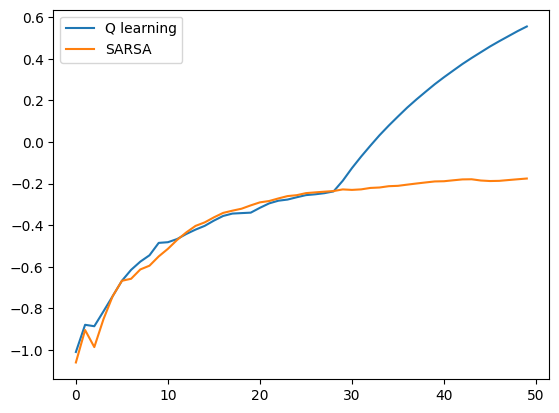

In [46]:
# TODO: visualize your agent's performance
fig = plt.figure()
plt.plot(Data_plot1, label="Q learning")
plt.plot(Data_plot2, label="SARSA")
plt.legend()
plt.show()